# Exploratory Data Analysis (EDA)

Loads all CSV files from a user-defined folder and performs a structured EDA.

| Section | Content |
|---|---|
| **1. Per-File** | Descriptive stats · Kurtosis & Skewness · Histograms · Correlation matrix |
| **2. Aggregate** | Global stats on concatenated data · Cross-file summary · Aggregate histograms · Correlation matrices |

> Per-file **plots** are capped at `MAX_FILES_DISPLAY` to keep the output manageable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [2]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
load_from_dir = "../data/generated/replication/HEUN_ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-500_sde-ve_noise-exponential_20260421_162722"  # <-- set your folder here

# Max files for which per-file PLOTS are rendered (set None to plot all files)
MAX_FILES_DISPLAY = 5
# ─────────────────────────────────────────────────────────────────────────────

---
## 0. Data Loading

In [3]:
csv_paths = sorted(Path(load_from_dir).glob("*.csv"))
assert len(csv_paths) > 0, f"No CSV files found in '{load_from_dir}'"

dataframes = {p.stem: pd.read_csv(p) for p in csv_paths}
print(f"Loaded {len(dataframes)} file(s) from '{load_from_dir}'")

# Schema check
schemas = {name: tuple(df.columns.tolist()) for name, df in dataframes.items()}
unique_schemas = set(schemas.values())
if len(unique_schemas) == 1:
    cols = list(unique_schemas)[0]
    print(f"Shared schema ({len(cols)} columns): {cols}")
else:
    print(f"WARNING: {len(unique_schemas)} different schemas detected.")
    for schema in unique_schemas:
        count = sum(1 for v in schemas.values() if v == schema)
        print(f"  {schema}  →  {count} file(s)")

Loaded 1 file(s) from '../data/generated/replication/HEUN_ODE_NO_NO_REPL_RET_OTHER_UNCO_ep-500_sde-ve_noise-exponential_20260421_162722'
Shared schema (2051 columns): ('sample_idx', 'start_date', 'end_date', 'step_000', 'step_001', 'step_002', 'step_003', 'step_004', 'step_005', 'step_006', 'step_007', 'step_008', 'step_009', 'step_010', 'step_011', 'step_012', 'step_013', 'step_014', 'step_015', 'step_016', 'step_017', 'step_018', 'step_019', 'step_020', 'step_021', 'step_022', 'step_023', 'step_024', 'step_025', 'step_026', 'step_027', 'step_028', 'step_029', 'step_030', 'step_031', 'step_032', 'step_033', 'step_034', 'step_035', 'step_036', 'step_037', 'step_038', 'step_039', 'step_040', 'step_041', 'step_042', 'step_043', 'step_044', 'step_045', 'step_046', 'step_047', 'step_048', 'step_049', 'step_050', 'step_051', 'step_052', 'step_053', 'step_054', 'step_055', 'step_056', 'step_057', 'step_058', 'step_059', 'step_060', 'step_061', 'step_062', 'step_063', 'step_064', 'step_065', 

---
## 1. Per-File Statistics

For each CSV: descriptive statistics (mean, median, std, min, max), kurtosis, skewness, histograms, and correlation matrix.

### 1.1 Descriptive Statistics per File

In [4]:
summary_rows = []

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    desc   = num_df.describe()
    median = num_df.median().rename('median')
    kurt   = num_df.kurtosis().rename('kurtosis')
    skew   = num_df.skew().rename('skewness')

    extended = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    display(extended)

    # Collect for cross-file summary
    for col in num_df.columns:
        summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     num_df[col].mean(),
            'median':   num_df[col].median(),
            'std':      num_df[col].std(),
            'min':      num_df[col].min(),
            'max':      num_df[col].max(),
            'kurtosis': num_df[col].kurtosis(),
            'skewness': num_df[col].skew(),
        })

per_file_summary = pd.DataFrame(summary_rows)


────────────────────────────────────────────────────────────
  generated_samples
────────────────────────────────────────────────────────────


sample_idx  step_000  step_001  step_002  step_003  step_004  \
count      1048.0000 1048.0000 1048.0000 1048.0000 1048.0000 1048.0000   
mean        523.5000   -0.0002    0.0005   -0.0001    0.0002   -0.0009   
median      523.5000    0.0001    0.0014    0.0005    0.0009   -0.0010   
std         302.6758    0.0249    0.0238    0.0229    0.0244    0.0222   
min           0.0000   -0.2460   -0.1587   -0.1046   -0.1883   -0.1316   
25%         261.7500   -0.0121   -0.0115   -0.0135   -0.0116   -0.0127   
50%         523.5000    0.0001    0.0014    0.0005    0.0009   -0.0010   
75%         785.2500    0.0119    0.0130    0.0127    0.0119    0.0117   
max        1047.0000    0.1484    0.1561    0.1559    0.1336    0.1475   
kurtosis     -1.2000   12.7277    5.8553    3.8730    8.3518    5.3053   
skewness      0.0000   -0.7470   -0.0186    0.4159   -0.6632   -0.2854   

          step_005  step_006  step_007  step_008  step_009  step_010  \
count    1048.0000 1048.0000 1048.0000 1048.0000 1048.0000 1048.0000   
mean        0.0006    0.0006    0.0003    0.0009    0.0027    0.0013   
median     -0.0003    0.0006    0.0004    0.0007    0.0026    0.0009   
std         0.0224    0.0225    0.0242    0.0239    0.0238    0.0234   
min        -0.1691   -0.1467   -0.2019   -0.1200   -0.1878   -0.1619   
25%        -0.0110   -0.0118   -0.0122   -0.0123   -0.0105   -0.0111   
50%        -0.0003    0.0006    0.0004    0.0007    0.0026    0.0009   
75%         0.0119    0.0125    0.0123    0.0140    0.0152    0.0135   
max         0.1148    0.1021    0.1188    0.1473    0.1545    0.1705   
kurtosis    6.8013    4.3545    8.3038    4.5063    8.0698    7.5261   
skewness   -0.5424   -0.1176   -0.5313    0.1241   -0.1290   -0.1556   

          step_011  step_012  step_013  step_014  step_015  step_016  \
count    1048.0000 1048.0000 1048.0000 1048.0000 1048.0000 1048.0000   
mean        0.0010    0.0000    0.0010    0.0015    0.0003    0.0009   
median      0.0008   -0.0005    0.0010    0.0003   -0.0003    0.0009   
std         0.0248    0.0226    0.0252    0.0229    0.0236    0.0230   
min        -0.1260   -0.1171   -0.1867   -0.1118   -0.2143   -0.2097   
25%        -0.0106   -0.0119   -0.0118   -0.0106   -0.0117   -0.0116   
50%         0.0008   -0.0005    0.0010    0.0003   -0.0003    0.0009   
75%         0.0128    0.0119    0.0134    0.0135    0.0125    0.0117   
max         0.3300    0.1123    0.3191    0.2148    0.1428    0.2261   
kurtosis   34.4805    3.7779   27.6359   10.1094   12.9425   17.0988   
skewness    2.1772   -0.0581    1.5651    0.9782   -0.5525    0.3330   

          step_017  step_018  step_019  step_020  step_021  step_022  \
count    1048.0000 1048.0000 1048.0000 1048.0000 1048.0000 1048.0000   
mean        0.0009    0.0008   -0.0003    0.0001    0.0016   -0.0003   
median      0.0015    0.0009   -0.0009   -0.0006    0.0008   -0.0005   
std         0.0220    0.0237    0.0219    0.0241    0.0240    0.0232   
min        -0.1589   -0.1479   -0.0885   -0.1118   -0.0905   -0.1174   
25%        -0.0102   -0.0121   -0.0129   -0.0117   -0.0109   -0.0123   
50%         0.0015    0.0009   -0.0009   -0.0006    0.0008   -0.0005   
75%         0.0126    0.0129    0.0117    0.0120    0.0127    0.0117   
max         0.0974    0.1517    0.0962    0.1409    0.2838    0.2244   
kurtosis    5.8813    6.6329    1.6764    5.2211   22.1832   11.5694   
skewness   -0.7963    0.2147    0.1540    0.3709    2.3243    0.9485   

          step_023  step_024  step_025  step_026  step_027  step_028  \
count    1048.0000 1048.0000 1048.0000 1048.0000 1048.0000 1048.0000   
mean        0.0003    0.0009    0.0022    0.0002   -0.0002    0.0005   
median      0.0006    0.0006    0.0020    0.0005    0.0001    0.0008   
std         0.0226    0.0222    0.0234    0.0224    0.0226    0.0214   
min        -0.0891   -0.0969   -0.1459   -0.2281   -0.1788   -0.1247   
25%        -0.0120   -0.0115   -0.0105   -0.0107   -0.0112   -0.0117   
50%         0.0006    

### 1.2 Per-File Histograms
> Limited to the first `MAX_FILES_DISPLAY` files.

In [5]:
plot_items = list(dataframes.items())
if MAX_FILES_DISPLAY is not None:
    plot_items = plot_items[:MAX_FILES_DISPLAY]

for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    n_cols = len(num_df.columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, num_df.columns):
        data = num_df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
        mu, sigma = data.mean(), data.std()
        ax.axvline(mu, color='red',    linestyle='--', linewidth=1.2, label=f'mean={mu:.3f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.0)
        ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.0, label=f'\u00b11\u03c3={sigma:.3f}')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    fig.suptitle(f"Distributions \u2014 {name}", fontsize=13, fontweight='bold')
    plt.show()

ValueError: Image size of 819600x400 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 819600x400 with 2049 Axes>

### 1.3 Per-File Correlation Matrix
> Limited to the first `MAX_FILES_DISPLAY` files.

In [6]:
for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.shape[1] < 2:
        print(f"{name}: only one numeric column, correlation skipped.")
        continue

    corr = num_df.corr()
    size = max(4, len(corr) * 0.9 + 1)
    fig, ax = plt.subplots(figsize=(size, size * 0.8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"Correlation Matrix \u2014 {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

ValueError: Image size of 184510x147608 pixels is too large. It must be less than 2^16 in each direction.

Error in callback <function _draw_all_if_interactive at 0x000001B7B09F1BC0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Image size of 184510x147608 pixels is too large. It must be less than 2^16 in each direction.

In [ ]:
# ── Increments: x_t − x_{t-1} ──────────────────────────────────────────────
inc_summary_rows = []
inc_dataframes   = {}   # {name: diff_df}  reused in the aggregate cells below

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    diff_df = num_df.diff().dropna()          # shape (T-1, K)
    inc_dataframes[name] = diff_df

    desc   = diff_df.describe()
    median = diff_df.median().rename('median')
    kurt   = diff_df.kurtosis().rename('kurtosis')
    skew   = diff_df.skew().rename('skewness')

    extended  = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}  [increments]\n{'─'*60}")
    display(extended)

    for col in diff_df.columns:
        inc_summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     diff_df[col].mean(),
            'median':   diff_df[col].median(),
            'std':      diff_df[col].std(),
            'min':      diff_df[col].min(),
            'max':      diff_df[col].max(),
            'kurtosis': diff_df[col].kurtosis(),
            'skewness': diff_df[col].skew(),
        })

inc_per_file_summary = pd.DataFrame(inc_summary_rows)



────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000000_s0  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,2047.0000
mean,0.0000
median,-0.0002
std,0.0437
min,-0.3241
25%,-0.0249
50%,-0.0002
75%,0.0236
max,0.3183
kurtosis,6.2993



────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000001_s400  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,2047.0000
mean,-0.0000
median,-0.0003
std,0.0418
min,-0.3241
25%,-0.0235
50%,-0.0003
75%,0.0219
max,0.3183
kurtosis,7.6205



────────────────────────────────────────────────────────────
  raw_AAPL_1980-12-12_2026-04-10_w0000002_s800  [increments]
────────────────────────────────────────────────────────────


...

,log_adj_close
count,2047.0000
mean,-0.0000
median,-0.0000
std,0.0181
min,-0.0920
25%,-0.0108
50%,-0.0000
75%,0.0105
max,0.1343
kurtosis,2.5015



────────────────────────────────────────────────────────────
  raw_XOM_1962-01-02_2026-04-10_w0005551_s7600  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,2047.0000
mean,-0.0000
median,-0.0000
std,0.0203
min,-0.0971
25%,-0.0115
50%,-0.0000
75%,0.0113
max,0.1343
kurtosis,2.7832



────────────────────────────────────────────────────────────
  raw_XOM_1962-01-02_2026-04-10_w0005552_s8000  [increments]
────────────────────────────────────────────────────────────


,log_adj_close
count,2047.0000
mean,0.0000
median,-0.0000
std,0.0214
min,-0.0971
25%,-0.0122
50%,-0.0000
75%,0.0122
max,0.1343
kurtosis,2.1194


In [ ]:
# ── Aggregate increments statistics (all files combined) ────────────────────
inc_common_cols = sorted(
    set.intersection(*[set(d.columns) for d in inc_dataframes.values()])
)
inc_combined = pd.concat(
    [d[inc_common_cols] for d in inc_dataframes.values()],
    ignore_index=True
)
print(f"Increments combined: {len(inc_combined):,} rows x {len(inc_common_cols)} columns")
print(f"Columns: {inc_common_cols}\n")

desc   = inc_combined.describe()
median = inc_combined.median().rename('median')
kurt   = inc_combined.kurtosis().rename('kurtosis')
skew   = inc_combined.skew().rename('skewness')

inc_agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order     = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
inc_agg_stats = inc_agg_stats.reindex([r for r in row_order if r in inc_agg_stats.index])

print("Aggregate Descriptive Statistics — increments (all files combined):")
display(inc_agg_stats)

# ── Cross-file summary ───────────────────────────────────────────────────────
inc_cross_file = (
    inc_per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
inc_cross_file.columns = [f"{stat}_{agg}" for stat, agg in inc_cross_file.columns]
print("\nCross-file summary — increments:")
display(inc_cross_file)


Increments combined: 4,894,377 rows x 1 columns
Columns: ['log_adj_close']

Aggregate Descriptive Statistics — increments (all files combined):


,log_adj_close
count,4894377.0000
mean,-0.0000
median,-0.0000
std,0.0283
min,-1.3863
25%,-0.0133
50%,-0.0000
75%,0.0131
max,0.8855
kurtosis,31.9897



Cross-file summary — increments:


,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
log_adj_close,-0.0000,0.0000,-0.0000,0.0001,0.0265,0.0100,-0.1824,0.1179,0.2101,0.1254,11.9382,30.9088,0.2229,0.6227


In [ ]:
# Define your condition — edit this
def condition(col: pd.Series) -> pd.Series:
    return (col > 1) & (col.abs() == col.abs().max())   # example: largest positive spike

# ── Search across all files ──────────────────────────────────────────────────
hits = []
for name, diff_df in inc_dataframes.items():
    for col in inc_common_cols:
        mask = condition(diff_df[col])
        matched = diff_df[col][mask]
        if matched.empty:
            continue
        # diff_df index = original df index - 1 (due to .diff().dropna())
        for idx, val in matched.items():
            hits.append({
                'file':        name,
                'column':      col,
                'diff_index':  idx,               # position in the diff series
                'orig_index':  idx + 1,           # corresponding row in original df
                'value':       val,
            })

hits_df = pd.DataFrame(hits)
display(hits_df)


""


---
## 2. Aggregate Statistics

Statistics computed over **all files combined** (rows from every CSV concatenated).
The cross-file summary shows per-column statistics averaged across files, giving a
sense of how consistent individual files are relative to the global distribution.

### 2.1 Aggregate Descriptive Statistics

In [ ]:
# Build combined dataset on the intersection of numeric columns
common_cols = sorted(
    set.intersection(*[set(df.select_dtypes(include='number').columns)
                       for df in dataframes.values()])
)
combined_df = pd.concat(
    [df[common_cols] for df in dataframes.values()],
    ignore_index=True
)
print(f"Combined dataset: {len(combined_df):,} rows x {len(common_cols)} columns")
print(f"Columns: {common_cols}\n")

# Extended describe
desc   = combined_df.describe()
median = combined_df.median().rename('median')
kurt   = combined_df.kurtosis().rename('kurtosis')
skew   = combined_df.skew().rename('skewness')

agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order  = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
agg_stats  = agg_stats.reindex([r for r in row_order if r in agg_stats.index])

print("Aggregate Descriptive Statistics (all files combined):")
display(agg_stats)

Combined dataset: 4,896,768 rows x 1 columns
Columns: ['log_adj_close']

Aggregate Descriptive Statistics (all files combined):


,log_adj_close
count,4896768.0000
mean,0.0005
median,0.0000
std,0.0202
min,-0.8434
25%,-0.0088
50%,0.0000
75%,0.0095
max,0.6931
kurtosis,40.4390


### 2.2 Cross-File Summary

Mean and standard deviation of each per-file statistic, grouped by column.
High std values indicate heterogeneity across files.

In [ ]:
cross_file = (
    per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
cross_file.columns = [f"{stat}_{agg}" for stat, agg in cross_file.columns]
display(cross_file)

,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
log_adj_close,0.0005,0.0004,0.0000,0.0001,0.0190,0.0068,-0.1627,0.1081,0.1250,0.0703,15.7965,48.7390,-0.3508,1.7583


### 2.3 Aggregate Histograms

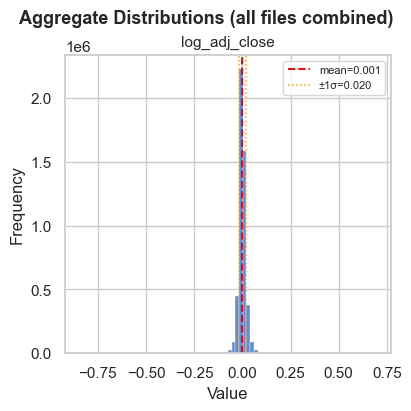

In [ ]:
n_cols = len(common_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    data = combined_df[col].dropna()
    ax.hist(data, bins=80, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red',    linestyle='--', linewidth=1.4, label=f'mean={mu:.3f}')
    ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.1)
    ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.1, label=f'\u00b11\u03c3={sigma:.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle("Aggregate Distributions (all files combined)", fontsize=13, fontweight='bold')
plt.show()

### 2.4 Aggregate Correlation Matrices

Two complementary views:
- **Left** — correlation computed on the full concatenated dataset
- **Right** — element-wise mean of per-file correlation matrices (preserves within-file structure)

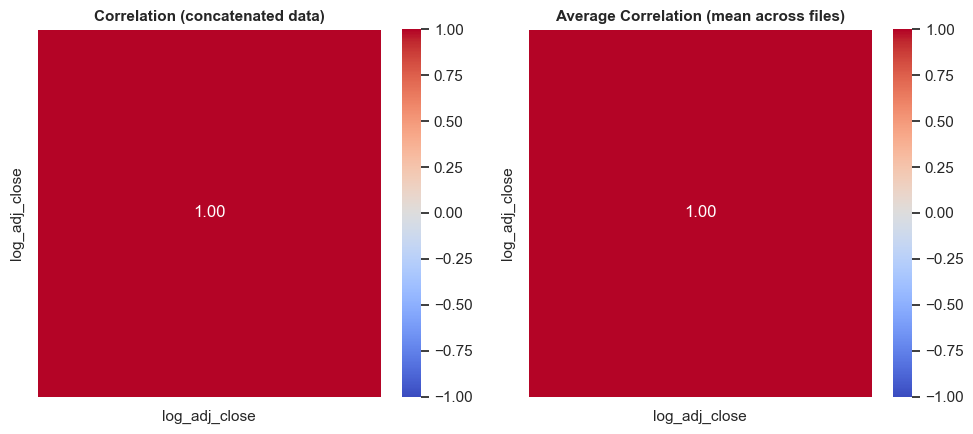

In [ ]:
# Per-file correlation matrices stacked
corr_stack = np.array([
    df[common_cols].corr().values
    for df in dataframes.values()
    if df[common_cols].shape[0] > 1
])
avg_corr = pd.DataFrame(corr_stack.mean(axis=0), index=common_cols, columns=common_cols)

size = max(5, len(common_cols) * 1.2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size * 0.9))

# Left: concatenated
corr_combined = combined_df.corr()
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation (concatenated data)", fontsize=11, fontweight='bold')

# Right: average across files
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Average Correlation (mean across files)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()